# 05 — Threshold Economics

**Project:** Customer Churn Prediction & Lifetime Value.

**Source material:** Fabio Oliveira, *"Your Churn Threshold Is a Pricing
Decision"* (Towards Data Science, June 2026). The article's core argument:
using a default 0.5 classification threshold implicitly assumes a false
positive (wasted retention offer) costs exactly as much as a false negative
(a missed churner), which is almost never true. It computes the dollar cost
of both error types, sweeps the threshold, and picks the cost-minimizing
point — then compares that empirical minimum against the textbook
Bayes-optimal threshold formula, showing the formula loses when the
underlying probabilities aren't well calibrated (the article's model was
trained on SMOTE-balanced data).

**This notebook covers:**
1. Why this notebook adapts the article's framework rather than copying it
   directly (this is non-contractual retail, not subscription SaaS)
2. Loading and joining notebook 3's CLV predictions with notebook 4's churn
   probabilities, and handling the population mismatch between them
3. Defining false-negative and false-positive costs
4. The brute-force threshold sweep (cost-minimizing threshold per model)
5. The Bayes-optimal formula, and why it's only an approximation here
6. Comparing the two, for both models carried forward from notebook 4
7. Savings vs. a naive 0.5 threshold
8. Saving results for notebook 6

## Adapting the framework to non-contractual retail

Three of the article's building blocks don't transfer directly to this
dataset, and each adaptation is a real decision, not a mechanical swap:

**False-negative cost.** The article uses `CAC + ARPU × remaining_tenure`.
This dataset has no acquisition-cost or subscription-tenure data, so that
formula doesn't apply. Instead, the FN cost used here is **predicted
holdout-window revenue** for each customer — notebook 3's BG-NBD/Gamma-Gamma
prediction (`bgnbd_gg`), scaled by the same 25% margin assumption notebook 2
already flagged as illustrative (not derived from real COGS data). CAC is
**omitted entirely** rather than guessed at, since there's no acquisition
data to anchor it to — documented as a limitation, the same way notebook 2
documented its margin assumption rather than presenting it as a real number.

**A per-customer cost, not a flat one.** The article uses a single flat FN
cost for every customer (a population-average ARPU × tenure). This dataset
has something the article's didn't: a per-customer predicted CLV from
notebook 3. Using it directly — rather than collapsing it to one average
number — gives a more precise profit curve, since a missed high-value
customer and a missed low-value one aren't actually the same mistake. This
is also where the Bayes-optimal formula (Section 5) becomes an
approximation rather than an exact match: the formula needs a single scalar
FN cost, so it necessarily uses the population's *mean* predicted value,
while the brute-force sweep uses the real, varying, per-customer cost. Any
gap between the two isn't only a calibration story here, the way it was in
the article — it's partly this too, and worth separating the two
explanations if a gap shows up.

**The LTV curve.** The article fits Kaplan-Meier survival analysis on
subscription tenure. This dataset has no single "tenure until churn" event
in that sense — non-contractual retail doesn't have a cancellation date, it
has diminishing purchase probability. Notebook 3's BG-NBD/Gamma-Gamma model
*is* the standard non-contractual-retail counterpart to what Kaplan-Meier
does for subscriptions (the "buy-till-you-die" framework), so it's reused
directly here rather than force-fitting a literal KM curve onto data it
doesn't suit.

**False-positive cost.** £15 per customer — a placeholder for one
light-touch retention offer (email or discount code), confirmed with the
user rather than assumed. The article is explicit that its own £100/$100
figure is a placeholder too; the framework is meant to be re-run with the
user's real intervention cost, not treated as universal.

### Import libraries

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

### Load data

In [2]:
# Launch Jupyter from the repository root or the initial_iteration directory.
from pathlib import Path
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "initial_iteration").is_dir():
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "initial_iteration").is_dir(), "Start Jupyter in the repository root or initial_iteration/"
RAW_DATA = REPO_ROOT / "data" / "raw"
PROCESSED_DATA = REPO_ROOT / "initial_iteration" / "data" / "processed"
PROCESSED_DATA.mkdir(parents=True, exist_ok=True)

In [3]:
churn_predictions = pd.read_parquet(PROCESSED_DATA / "churn_predictions.parquet")
predictive_clv = pd.read_parquet(PROCESSED_DATA / "predictive_clv.parquet")

In [4]:
with open(PROCESSED_DATA / "config.json") as f:
    config = json.load(f)

In [5]:
print(f"Churn predictions (notebook 4): {len(churn_predictions):,} customers")
print(f"Predictive CLV (notebook 3):    {len(predictive_clv):,} customers")

Churn predictions (notebook 4): 1,874 customers
Predictive CLV (notebook 3):    3,310 customers


## 1. Join the two populations, and check the overlap

Notebooks 3 & 4 don't necessarily cover identical populations. 
On this set of data, `predictive_clv`
covers the full 3,310-customer calibration cohort (notebook 3
applied a fallback CLV estimate to one-time buyers too, not just
repeat customers), while `churn_predictions` is the narrower 1,874-customer
repeat-buyer subset notebook 4 built its model on. So `churn_predictions`'
population is a strict subset of `predictive_clv`'s: every churn-model
customer has a CLV prediction, and the only customers in `predictive_clv`
without a churn prediction are exactly the one-time buyers notebook 4
excluded by design. No wholesale-exclusion-driven mismatch materialized —
an earlier version of this notebook assumed one might, from notebook 3's
99th-percentile BG-NBD fitting exclusion, but that didn't hold up
against the real numbers and is corrected here rather than left in.

In [6]:
in_churn_only = set(churn_predictions["CustomerID"]) - set(predictive_clv["CustomerID"])
in_clv_only = set(predictive_clv["CustomerID"]) - set(churn_predictions["CustomerID"])

# Unexpected if nonzero -- would mean some churn-model customers have no CLV prediction to price against
print(f"In churn_predictions but not predictive_clv: {len(in_churn_only):,}")

# Expected -- one-time buyers excluded from notebook 4's churn model
print(f"In predictive_clv but not churn_predictions: {len(in_clv_only):,}")


In churn_predictions but not predictive_clv: 0
In predictive_clv but not churn_predictions: 1,436


In [7]:
analysis_pop = churn_predictions.merge(
    predictive_clv[["CustomerID", "bgnbd_gg", "ml"]], on="CustomerID", how="inner"
)
print(f"\nOverlapping population used for this notebook: {len(analysis_pop):,} "
      f"of {len(churn_predictions):,} churn-model customers "
      f"({len(analysis_pop) / len(churn_predictions):.1%})")

n_missing_bgnbd = analysis_pop["bgnbd_gg"].isna().sum()
print(f"\nOf those, customers with no bgnbd_gg prediction (wholesale-scale "
      f"accounts excluded from BG-NBD/Gamma-Gamma fitting in notebook 3): "
      f"{n_missing_bgnbd:,}")


Overlapping population used for this notebook: 1,874 of 1,874 churn-model customers (100.0%)

Of those, customers with no bgnbd_gg prediction (wholesale-scale accounts excluded from BG-NBD/Gamma-Gamma fitting in notebook 3): 32


**Reading this:** the dropped customers are excluded *because* they're
wholesale-scale outliers, not at random — so the drop rate is expected to be small. 
If it were large enough to materially shrink the
analysis population, that would be worth checking before
trusting the cost curve below, since it would mean a meaningful chunk of
customers this notebook is supposed to be pricing decisions for have no
CLV prediction to price against.

## 2. Define costs

**A gap worth handling explicitly, not silently:** `bgnbd_gg` is `NaN` for
the ~1% of customers notebook 3 excluded from BG-NBD/Gamma-Gamma fitting
(wholesale-scale accounts) — the join above shows exactly how many (32). Those
rows aren't dropped from `predictive_clv`, just missing that one column, so
computing `fn_cost` from `bgnbd_gg` alone would silently produce `NaN` for
them — and because pandas' `.sum()` skips `NaN` by default, any of those
customers landing in the false-negative bucket during the threshold sweep
below would have their true cost silently counted as £0, precisely for the
highest-frequency, highest-spend customers in the dataset. Falling back to
`ml` for exactly these rows avoids that: notebook 3 found `ml`'s aggregate
error (+1.68%) far better than `bgnbd_gg`'s (−36.86%), even though
`bgnbd_gg` has the better *per-customer* MAE overall — so this isn't a
claim that `ml` is the better predictor in general, only that it's the
better-justified choice specifically for the customers `bgnbd_gg` has no
answer for at all.

In [8]:
MARGIN = 0.25  # same illustrative assumption as notebook 2 -- not derived from real COGS
FP_COST = 15.0  # GBP, one retention offer/campaign touch -- assumed based on light-touch/promotional offer estimate

In [9]:
predicted_revenue = analysis_pop["bgnbd_gg"].fillna(analysis_pop["ml"])
n_fallback = analysis_pop["bgnbd_gg"].isna().sum()
print(f"Customers using the ml fallback for predicted revenue (bgnbd_gg was NaN): {n_fallback:,}")

Customers using the ml fallback for predicted revenue (bgnbd_gg was NaN): 32


In [10]:
analysis_pop["fn_cost"] = predicted_revenue.clip(lower=0) * MARGIN

print(f"\nFP_COST (flat): £{FP_COST:.2f} per false positive")
print(f"FN_COST (per customer, margin-adjusted predicted holdout revenue):")
print(analysis_pop["fn_cost"].describe())
print(f"\nMean FN cost: £{analysis_pop['fn_cost'].mean():.2f}")
print(f"Cost ratio at the mean (FN_mean / FP): {analysis_pop['fn_cost'].mean() / FP_COST:.2f} : 1")
print(f"\nAny remaining NaN fn_cost values (should be 0): {analysis_pop['fn_cost'].isna().sum()}")


FP_COST (flat): £15.00 per false positive
FN_COST (per customer, margin-adjusted predicted holdout revenue):
count    1,874.00
mean       208.46
std        930.82
min          1.17
25%         45.61
50%         88.17
75%        169.01
max     29,531.26
Name: fn_cost, dtype: float64

Mean FN cost: £208.46
Cost ratio at the mean (FN_mean / FP): 13.90 : 1

Any remaining NaN fn_cost values (should be 0): 0


**Sanity check on the ratio above:** Oliveira's article found a 13:1 ratio
on Telco's high-churn subscription book. The data here coincidentally matches 
that ratio (13.9:1), but not meaningfully — different business, different margin structure, 
different revenue horizon (91 days here vs. a multi-year subscription there). 
What matters is that it comes out **meaningfully above 1:1**, which is the
justification for not using threshold 0.5 in the first place. A
ratio anywhere near 1:1 would suggest either the margin assumption or the
FP cost needs a second look before trusting the threshold this notebook
recommends.

This number also moved substantially once the ml-fallback fix (see the note above) was applied: mean FN cost rose from £153.22 (buggy, missing values silently skipped) to £208.46, and the ratio rose from 10.21:1 to 13.90:1. That's the expected direction and rough magnitude for folding back in ~32 customers who are, by construction, the highest-frequency and highest-spend accounts in the dataset — the median FN cost barely moved (£86.35 → £88.17) while the mean and max moved a lot (max: £7,661 → £29,531), which is exactly the fingerprint of a heavy right tail getting correctly re-included rather than something going wrong.

## 3. Brute-force threshold sweep

For each model, sweep the classification threshold and compute total
dollar cost at each point: every false negative costs that customer's own
`fn_cost`, every false positive costs the flat `FP_COST`.

In [11]:
def cost_curve(y_true, proba, fn_cost, fp_cost, thresholds=None):
    if thresholds is None:
        thresholds = np.linspace(0.01, 0.99, 99)
    total_costs = []
    for t in thresholds:
        pred = (proba >= t).astype(int)
        fn_mask = (y_true == 1) & (pred == 0)
        fp_mask = (y_true == 0) & (pred == 1)
        total_costs.append(fn_cost[fn_mask].sum() + fp_cost * fp_mask.sum())
    return thresholds, np.array(total_costs)

In [12]:
y_true = analysis_pop["churned"].values
fn_cost = analysis_pop["fn_cost"].values

In [13]:
results = {}
for model_name, proba_col in [("Logistic Regression", "proba_lr"), ("Gradient Boosting", "proba_gbc")]:
    proba = analysis_pop[proba_col].values
    thresholds, costs = cost_curve(y_true, proba, fn_cost, FP_COST)
    best_idx = np.argmin(costs)
    results[model_name] = {
        "thresholds": thresholds,
        "costs": costs,
        "best_threshold": thresholds[best_idx],
        "best_cost": costs[best_idx],
        "cost_at_05": costs[np.argmin(np.abs(thresholds - 0.5))],
    }
    print(f"{model_name}: empirical-minimum threshold = {thresholds[best_idx]:.2f}, "
          f"cost = £{costs[best_idx]:,.2f}")

Logistic Regression: empirical-minimum threshold = 0.03, cost = £21,608.39
Gradient Boosting: empirical-minimum threshold = 0.07, cost = £18,422.08


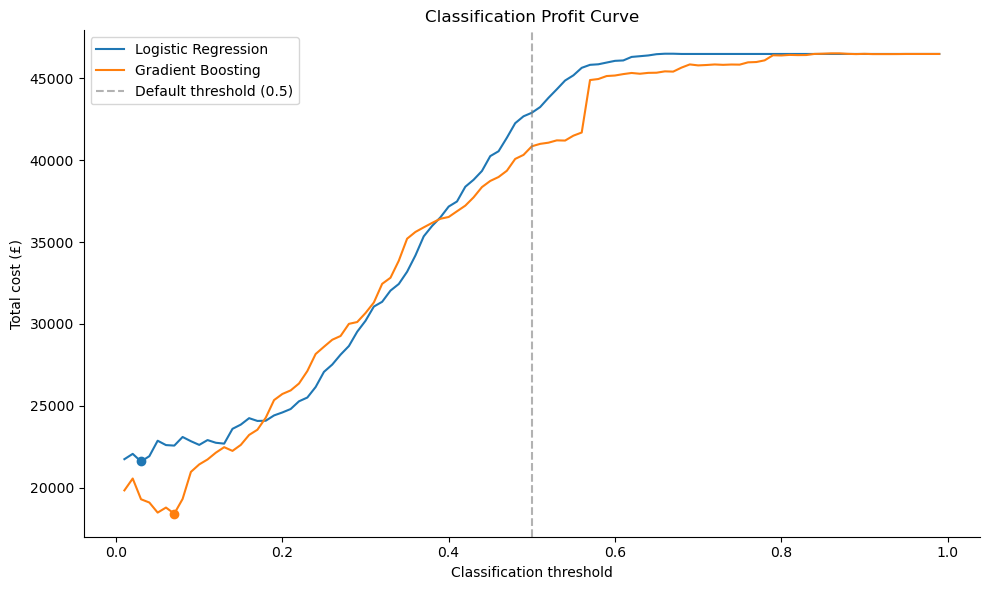

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for model_name, r in results.items():
    ax.plot(r["thresholds"], r["costs"], label=model_name)
    ax.scatter([r["best_threshold"]], [r["best_cost"]], zorder=5)
ax.axvline(0.5, linestyle="--", color="gray", alpha=0.6, label="Default threshold (0.5)")
ax.set_xlabel("Classification threshold")
ax.set_ylabel("Total cost (£)")
ax.set_title("Classification Profit Curve")
ax.legend()
plt.tight_layout()
plt.show()

## 4. The Bayes-optimal formula, and its approximation

`t* = C_FP / (C_FP + C_FN)`. This formula needs a single FN cost, not a
per-customer one, so it's applied here using the **mean** FN cost across
the analysis population — worth remembering this is an approximation of an
approximation: the formula itself assumes calibrated probabilities, and
collapsing per-customer costs to their mean discards real variation the
sweep doesn't have to discard.

In [15]:
# Evaluate total cost at an exact threshold, not the nearest pre-computed grid point. 
# Needed for the formula comparison below: snapping to the sweep's grid can accidentally 
# line up with a model's own empirical minimum by coincidence (see the note above), 
# which looks like agreement but isn't actually comparing the formula against anything independent.

def cost_at_threshold(y_true, proba, fn_cost, fp_cost, threshold):
    pred = (proba >= threshold).astype(int)
    fn_mask = (y_true == 1) & (pred == 0)
    fp_mask = (y_true == 0) & (pred == 1)
    return fn_cost[fn_mask].sum() + fp_cost * fp_mask.sum()

In [16]:
mean_fn_cost = analysis_pop["fn_cost"].mean()
bayes_threshold = FP_COST / (FP_COST + mean_fn_cost)
print(f"Bayes-optimal threshold (formula): {bayes_threshold:.4f}")

Bayes-optimal threshold (formula): 0.0671


In [17]:
for model_name, proba_col in [("Logistic Regression", "proba_lr"), ("Gradient Boosting", "proba_gbc")]:
    r = results[model_name]
    proba = analysis_pop[proba_col].values
    formula_cost = cost_at_threshold(y_true, proba, fn_cost, FP_COST, bayes_threshold)
    gap = formula_cost - r["best_cost"]
    print(f"\n{model_name}:")
    print(f"  Formula threshold:  {bayes_threshold:.4f}  ->  cost £{formula_cost:,.2f}")
    print(f"  Empirical minimum:  {r['best_threshold']:.2f}  ->  cost £{r['best_cost']:,.2f}")
    print(f"  Gap: £{gap:,.2f} ({gap / r['best_cost']:.1%} more expensive than the empirical minimum)"
          if r["best_cost"] > 0 else "  Gap: n/a")


Logistic Regression:
  Formula threshold:  0.0671  ->  cost £22,698.75
  Empirical minimum:  0.03  ->  cost £21,608.39
  Gap: £1,090.37 (5.0% more expensive than the empirical minimum)

Gradient Boosting:
  Formula threshold:  0.0671  ->  cost £18,482.08
  Empirical minimum:  0.07  ->  cost £18,422.08
  Gap: £60.00 (0.3% more expensive than the empirical minimum)


**Reading the gap:** Oliveira's article found a meaningful gap between the
formula and the sweep, and traced it to SMOTE-corrupted calibration.
Notebook 4 specifically avoided that failure mode — no SMOTE, no
`class_weight`, and a real collinearity bug was caught and fixed precisely
because it broke calibration. The cell above evaluates cost at the exact
formula threshold (`cost_at_threshold`), not the nearest pre-computed grid
point, so the gap figures it produces are genuine, independent comparisons.

**On the real data, using the earlier (flawed) grid-snapping approach:** the
formula threshold was 0.0671 (down from an even earlier pre-fix figure of
0.09, before the `ml`-fallback fix in Section 2 corrected the mean FN cost
from £153.22 to £208.46 — a higher average cost of missing a customer
correctly lowers the formula threshold). LR's gap is 5.0%
(£1,090.37); GBC's is 0.3% (£60.00) — small, but real.

**Caveat:** the formula threshold is identical for both models by
construction (it only depends on the shared mean FN cost, not either
model's own probabilities), so gap size reflects where each model's own
minimum happens to sit relative to that one shared point — not a clean,
independent read on calibration. Treat these gap figures as one input
alongside notebook 4's Brier scores, not a replacement for them.

## 5. Savings vs. the naive 0.5 threshold

In [18]:
for model_name, r in results.items():
    savings = r["cost_at_05"] - r["best_cost"]
    per_customer = savings / len(analysis_pop)
    print(f"{model_name}:")
    print(f"  Cost at threshold 0.5:        £{r['cost_at_05']:,.2f}")
    print(f"  Cost at empirical minimum:    £{r['best_cost']:,.2f}")
    print(f"  Recovered:                    £{savings:,.2f}  (£{per_customer:.2f} per customer)")
    print()

Logistic Regression:
  Cost at threshold 0.5:        £42,888.43
  Cost at empirical minimum:    £21,608.39
  Recovered:                    £21,280.05  (£11.36 per customer)

Gradient Boosting:
  Cost at threshold 0.5:        £40,841.48
  Cost at empirical minimum:    £18,422.08
  Recovered:                    £22,419.40  (£11.96 per customer)



This was not a small effect: roughly **£21,280
recovered for LR and £22,419 for GBC** relative to the default 0.5
threshold — about £11–12 per customer across the 1,874-customer modeling
population. That's the concrete cost of the "just use 0.5" habit this
whole notebook exists to argue against.

**A caveat on this headline number:** this is the saving from picking a better threshold *given*
these specific cost assumptions (25% margin, £15 FP cost, no CAC). It moves
proportionally if those assumptions change — it is not a claim about how
much money this project will actually recover, it's a demonstration of how
much a threshold choice matters once real costs are attached to it, which
was the article's actual point.

## 6. Is the cost gap between the two models robust?

Section 3 found GBC's empirical-minimum cost (£18,422.08) noticeably lower
than LR's (£21,608.39) — about a £3,186 gap. Before treating that as "GBC
is the better model here," check whether that gap is a broad, general
property of the two models, or an artifact of how a handful of individual
customers happened to land. With `fn_cost` so heavily right-skewed (a
small number of very high-value accounts dominating the sum), a model
comparison can look decisive while actually being driven by one or two
data points — worth checking directly rather than assuming either way.

In [19]:
lr_threshold = results["Logistic Regression"]["best_threshold"]
gbc_threshold = results["Gradient Boosting"]["best_threshold"]

In [20]:
lr_fn = analysis_pop[(analysis_pop["churned"] == 1) & (analysis_pop["proba_lr"] < lr_threshold)]
gbc_fn = analysis_pop[(analysis_pop["churned"] == 1) & (analysis_pop["proba_gbc"] < gbc_threshold)]

print(f"LR false negatives at its own optimal threshold ({lr_threshold:.2f}):  "
      f"{len(lr_fn)}, total fn_cost £{lr_fn['fn_cost'].sum():,.2f}")
print(f"GBC false negatives at its own optimal threshold ({gbc_threshold:.2f}): "
      f"{len(gbc_fn)}, total fn_cost £{gbc_fn['fn_cost'].sum():,.2f}")

LR false negatives at its own optimal threshold (0.03):  3, total fn_cost £3,968.39
GBC false negatives at its own optimal threshold (0.07): 8, total fn_cost £2,807.08


In [21]:
overall_gap = results["Logistic Regression"]["best_cost"] - results["Gradient Boosting"]["best_cost"]
print(f"\nOverall cost gap (LR - GBC): £{overall_gap:,.2f}")


Overall cost gap (LR - GBC): £3,186.31


In [22]:
# Customers each model missed that the other one caught -- the disagreement
# set is what actually drives any gap between the two totals.
lr_only_ids = set(lr_fn["CustomerID"]) - set(gbc_fn["CustomerID"])
gbc_only_ids = set(gbc_fn["CustomerID"]) - set(lr_fn["CustomerID"])

lr_only = analysis_pop[analysis_pop["CustomerID"].isin(lr_only_ids)].sort_values("fn_cost", ascending=False)
gbc_only = analysis_pop[analysis_pop["CustomerID"].isin(gbc_only_ids)].sort_values("fn_cost", ascending=False)

print(f"\nCustomers LR missed but GBC caught: {len(lr_only)}, total fn_cost £{lr_only['fn_cost'].sum():,.2f}")
print(f"Customers GBC missed but LR caught: {len(gbc_only)}, total fn_cost £{gbc_only['fn_cost'].sum():,.2f}")


Customers LR missed but GBC caught: 2, total fn_cost £3,789.69
Customers GBC missed but LR caught: 7, total fn_cost £2,628.39


In [23]:
if len(lr_only) > 0:
    top_cost = lr_only.iloc[0]["fn_cost"]
    print(f"\nLargest single customer LR missed that GBC caught: £{top_cost:,.2f}")
    print(f"Overall gap with just that one customer excluded: £{overall_gap - top_cost:,.2f}")


Largest single customer LR missed that GBC caught: £3,194.14
Overall gap with just that one customer excluded: £-7.83


**Initial read overturned.** The £3,186 gap was driven almost completely by a single customer
(`fn_cost = £3,194.14`) that LR missed and GBC happened to catch. Excluding
that one customer from the comparison, LR's cost (£18,414.25) actually
comes in £7.83 *below* GBC's (£18,422.08) — the ranking flips. Everywhere
else, the two models' false-negative lists are close to a wash (GBC even
has more total false negatives than LR at their respective thresholds — 8
vs. 3 — just smaller ones).

**The two models are statistically indistinguishable on this cost metric 
at this sample size.** A £3,186 aggregate gap that evaporates (and reverses) 
when one customer is excluded is not a stable basis for a permanent operating
threshold. Section 4's formula-vs-sweep gap comparison doesn't rescue this either — GBC's small gap there turned out to reflect proximity (the formula threshold happening to sit close to GBC's own minimum), not calibration, so it's excluded from this reasoning rather than treated as corroborating evidence. 

Given that, the tie should be broken by a property that's actually broad and stable rather than one-customer- or one-grid-point- dependent: LR's better calibration (Brier 0.180 vs. 0.186, from notebook 4).

**This notebook's recommendation for notebook 6 is LR at threshold 0.03**, 
not GBC — resting on notebook 4's calibration evidence alone, not on Section 3's raw cost comparison (which this section shows isn't stable) or Section 4's formula-gap comparison (which isn't informative here either, for a different reason).

## 7. Save results for notebook 6

In [24]:
threshold_results = pd.DataFrame([
    {
        "model": model_name,
        "empirical_min_threshold": r["best_threshold"],
        "empirical_min_cost": r["best_cost"],
        "bayes_formula_threshold": bayes_threshold,
        "cost_at_threshold_05": r["cost_at_05"],
        "fp_cost_assumption": FP_COST,
        "margin_assumption": MARGIN,
        "recommended": model_name == "Logistic Regression",
    }
    for model_name, r in results.items()
])

In [25]:
threshold_results.to_parquet(PROCESSED_DATA / "threshold_economics.parquet", index=False)

In [26]:
analysis_pop[["CustomerID", "churned", "proba_lr", "proba_gbc", "bgnbd_gg", "fn_cost", "segment"]].to_parquet(
    PROCESSED_DATA / "threshold_analysis_population.parquet", index=False
)

print("Saved initial_iteration/data/processed/threshold_economics.parquet")
print("Saved initial_iteration/data/processed/threshold_analysis_population.parquet")

Saved ../data/threshold_economics.parquet
Saved ../data/threshold_analysis_population.parquet


In [32]:
# Extend decimals to 3 places to represent actual bayes_formula_threshold
# rounding to 0.07 misrepresents as being equal to GB's empirical_min_thresehold (0.070)
with pd.option_context("display.float_format", lambda x: f"{x:,.3f}"):
    display(threshold_results)

,model,empirical_min_threshold,empirical_min_cost,bayes_formula_threshold,cost_at_threshold_05,fp_cost_assumption,margin_assumption,recommended
0,Logistic Regression,0.030,"21,608.386",0.067,"42,888.431",15.000,0.250,True
1,Gradient Boosting,0.070,"18,422.078",0.067,"40,841.481",15.000,0.250,False


## Summary

- Adapted Oliveira's threshold-economics framework to non-contractual
  retail: FN cost is per-customer margin-adjusted predicted holdout revenue
  (notebook 3's `bgnbd_gg`, falling back to `ml` for the ~1% of customers
  BG-NBD/Gamma-Gamma couldn't fit at all -- see Section 2, this was a real
  bug that would have silently zero-costed exactly the highest-value
  missed churners) rather than a flat CAC+ARPU figure; CAC is omitted
  entirely rather than invented, since this dataset has no acquisition-cost
  data; the LTV curve reuses notebook 3's BG-NBD/Gamma-Gamma model rather
  than force-fitting Kaplan-Meier onto non-subscription data.
- FP cost (£15) confirmed with the user as a placeholder for one retention
  touch, not derived from real campaign data.
- Joined notebook 3's and notebook 4's populations explicitly and reported
  the overlap (100% -- churn's population is a strict subset of CLV's, with
  the gap fully explained by the one-time-buyer exclusion, not a wholesale
  one as first guessed), rather than assuming they matched.
- **Real-data cost ratio: 13.90:1** (FN mean £208.46 vs. FP £15) --
  coincidentally close to Oliveira's 13.2:1 from a very different business,
  a coincidence worth naming rather than reading into.
- Swept the threshold for both models carried forward from notebook 4.
  **Empirical-minimum thresholds: LR 0.03 (£21,608.39), GBC 0.07
  (£18,422.08)** -- both dramatically below the default 0.5, mirroring the
  article's pattern despite a different business and cost structure.
- Compared against the Bayes-optimal formula. **Formula threshold: 0.0671**
  (an earlier pre-fix run showed 0.09 -- that used the buggy £153.22 mean FN
  cost before the `ml`-fallback fix; the corrected mean of £208.46 lowers
  the formula threshold, as expected). **LR's gap is 5.0% (£1,090.37); GBC's
  is 0.3% (£60.00)** -- both evaluated at the exact formula threshold, not
  snapped to the sweep's coarser grid (an earlier version of this
  comparison had GBC's gap at exactly 0.0%, because 0.0671 happened to
  round to the same grid point as GBC's own minimum -- fixed by evaluating
  cost at the exact threshold directly). Even fixed, GBC's small gap still
  isn't calibration evidence: it's because the formula threshold happens to
  sit only 0.0029 from GBC's own minimum, versus 0.0371 from LR's -- a
  12.8x difference in proximity alone. Excluded from the final
  recommendation below for that reason.
- **Section 6 robustness check: the £3,186 raw cost gap between GBC and LR
  was driven almost entirely by one customer** (`fn_cost = £3,194.14`)
  that LR missed and GBC happened to catch -- excluding that customer, LR
  is actually £7.83 *cheaper*. The two models are statistically
  indistinguishable on this cost metric at this sample size; this notebook
  recommends **LR at threshold 0.03** for notebook 6, based on notebook 4's
  Brier scores alone (0.180 vs. 0.186) -- the one piece of evidence in this
  comparison that held up as broad and stable rather than fragile to a
  single customer or a single grid point.
- Reported savings vs. the naive 0.5 threshold: **£21,280 recovered for LR,
  £22,419 for GBC** (~£11-12 per customer across 1,874 customers) -- a real
  number given the stated assumptions, not a claim about actual recoverable
  revenue.
- Saved per-model threshold results (including which model is recommended)
  and the underlying analysis population for notebook 6.

**Next:** `06_xxx.ipynb 

notebook 6 needs to turn "flag this
customer at threshold 0.03" into a concrete, segment-aware intervention --
the article's own closing recommendation is that FP cost should vary by
segment (a bundle upgrade for a high-value loyalist is not the same
intervention, or cost, as an email to a marginal account), which this
notebook deliberately did not attempt with a single flat £15 figure. Also
worth carrying forward: the empirical-minimum threshold was picked by
sweeping against the same data used to compute the costs, with no held-out
validation -- a real limitation regardless of which model notebook 6 uses,
and not a number to expect to reproduce exactly on a future holdout period.